In [1]:
print(";ln;ldsfg")

;ln;ldsfg


In [9]:
%pwd
import os
os.chdir("../")
#Just went one step bcakword with this directory....

%pwd

'd:\\mlops\\Crypto_Guardian'

Directory 'EDA_Results' created.


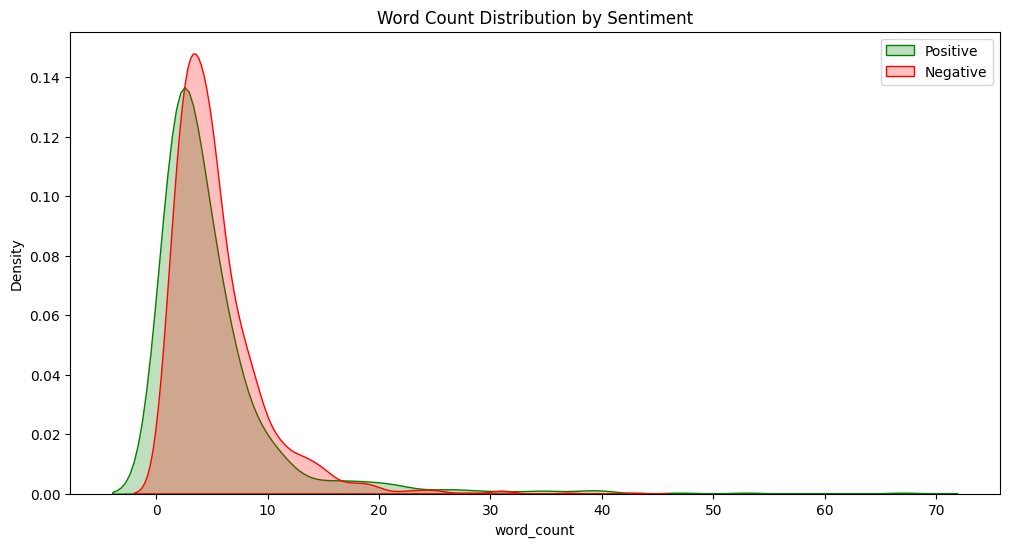

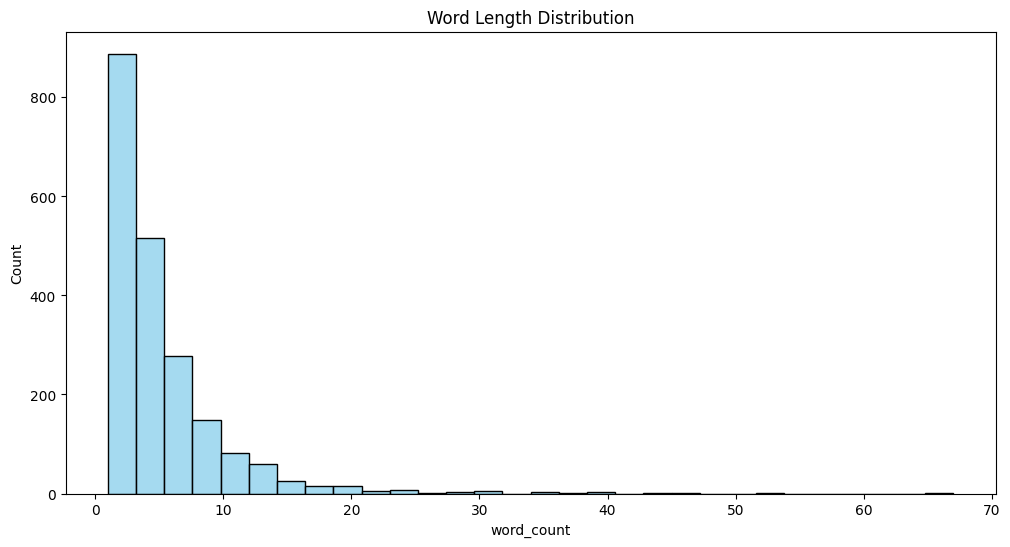

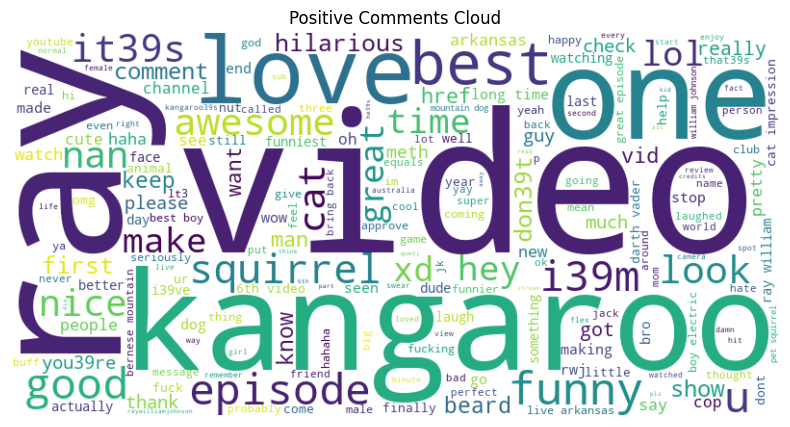

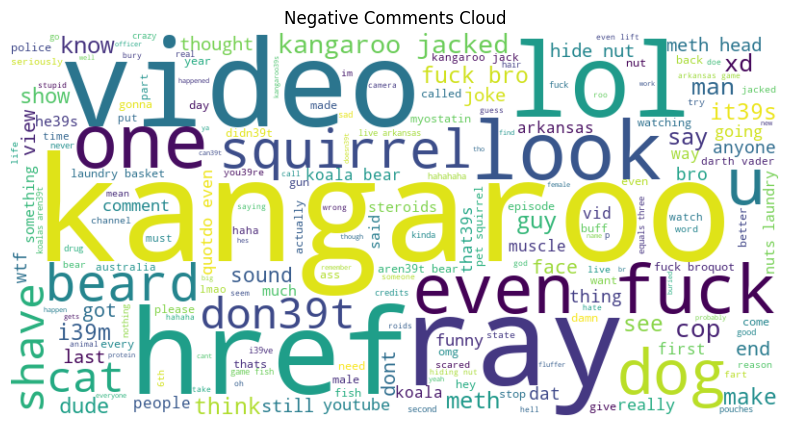

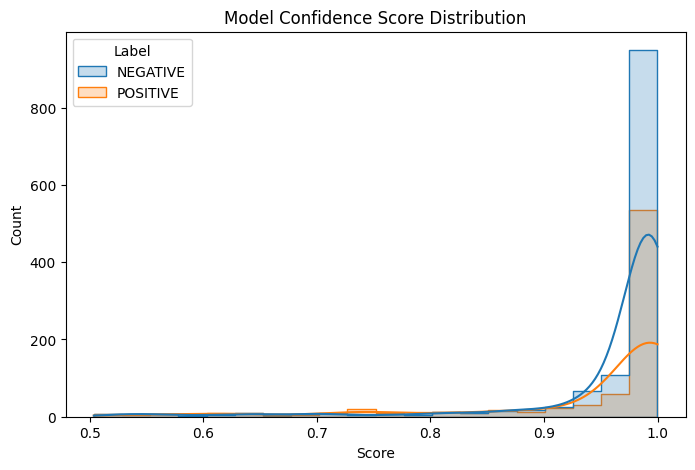

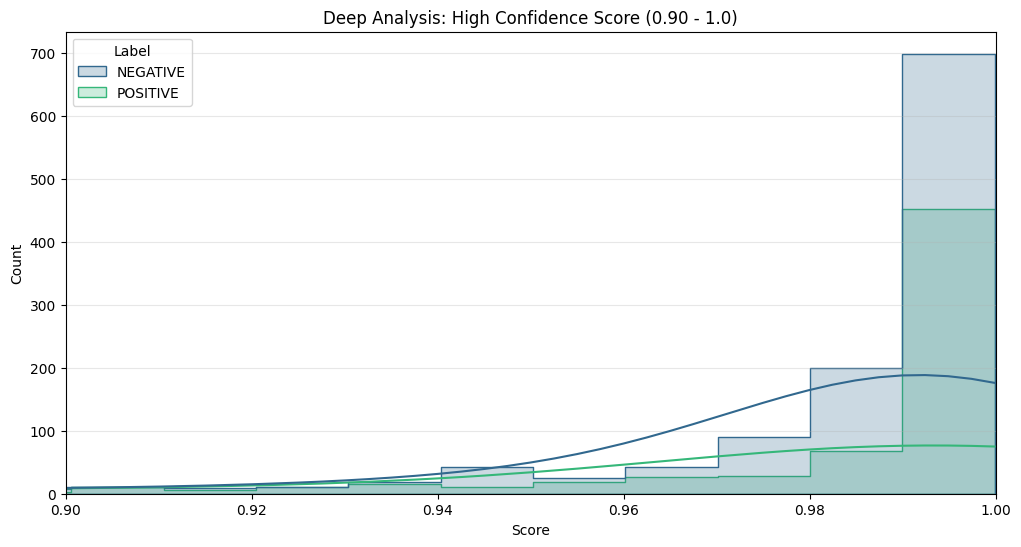

Saaare graphs 'EDA_Results' folder mein save ho gaye hain!


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud
import os

# 1. Path fix: Use raw string (r"") for Windows paths
data_path = r"D:\mlops\Crypto_Guardian\artifacts\data_cleaning\data.csv"
df = pd.read_csv(data_path)

def download_eda_report(df, output_dir="EDA_Results"):
    # Output directory banana agar nahi hai toh
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Directory '{output_dir}' created.")

    # Data Processing
    df['char_count'] = df['text'].astype(str).apply(len)
    df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

    # --- Plot 1: Word Count Distribution ---
    plt.figure(figsize=(12, 6))
    # Label filter fix: Check if labels are 0/1 or POSITIVE/NEGATIVE in your CSV
    # Yahan maine dono conditions handle ki hain
    pos_df = df[df['Label'].isin([1, 'POSITIVE'])]
    neg_df = df[df['Label'].isin([0, 'NEGATIVE'])]
    
    sns.kdeplot(pos_df['word_count'], fill=True, color="green", label="Positive")
    sns.kdeplot(neg_df['word_count'], fill=True, color="red", label="Negative")
    plt.title("Word Count Distribution by Sentiment")
    plt.legend()
    plt.savefig(f"{output_dir}/word_count_dist.png")
    plt.show()

    # --- Plot 2: Word Length Histogram ---
    plt.figure(figsize=(12, 6))
    sns.histplot(df["word_count"], bins=30, color='skyblue')
    plt.title("Word Length Distribution")
    plt.savefig(f"{output_dir}/word_length_hist.png")
    plt.show()
    
    # --- Function: WordCloud ---
    def save_wordcloud(data_subset, title, filename):
        text_data = ' '.join(data_subset['text'].astype(str))
        if len(text_data.strip()) > 0:
            wc = WordCloud(width=800, height=400, background_color='white').generate(text_data)
            plt.figure(figsize=(10, 5))
            plt.imshow(wc, interpolation='bilinear')
            plt.title(title)
            plt.axis('off')
            plt.savefig(f"{output_dir}/{filename}")
            plt.show()
        else:
            print(f"Bhai, {title} ke liye data nahi mila!")

    save_wordcloud(pos_df, "Positive Comments Cloud", "wc_positive.png")
    save_wordcloud(neg_df, "Negative Comments Cloud", "wc_negative.png")
    
    # --- Plot 3: Confidence Score Distribution ---
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x="Score", hue="Label", kde=True, element="step", bins=20)
    plt.title("Model Confidence Score Distribution")
    plt.savefig(f"{output_dir}/score_distribution.png")
    plt.show()
    
    # --- Plot 4: Zoomed High Confidence ---
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df, x="Score", hue="Label", kde=True,
                element="step", palette="viridis", bins=50)
    plt.xlim(0.90, 1.0)
    plt.title("Deep Analysis: High Confidence Score (0.90 - 1.0)")
    plt.grid(axis='y', alpha=0.3)
    plt.savefig(f"{output_dir}/high_confidence_zoom.png")
    plt.show()

    print(f"Saaare graphs '{output_dir}' folder mein save ho gaye hain!")

# Function call karein
download_eda_report(df)

In [7]:
from dataclasses import dataclass
from pathlib import Path

@dataclass
class EDAReportConfig:
    root_dir: Path
    data_path: Path 
    output_report: Path

In [10]:
from src.Crypto.constants import *
from src.Crypto.utils.helper import read_yaml,create_directories
from src.Crypto import logger

class ConfigurationManager:
    def __init__(self,config_file_path=CONFIG_FILE_PATH,
                      params_file_path = PARAMS_FILE_PATH,
                      schema_file_path = SCHEMA_FILE_PATH):
        self.config =read_yaml( config_file_path)
        self.parmas = read_yaml(params_file_path)
        self.schema = read_yaml(schema_file_path)
        
        # create_directories([self.config.artifacts_root])
        logger.debug(f"Till Now all the Yaml Files are Read Sucessfully...✅")
    def get_eda_report(self)->EDAReportConfig:
        config = self.config.eda_report
        create_directories([config.root_dir])
        
        eda_report_config = EDAReportConfig(
            root_dir=config.root_dir,
            data_path= config.data_path,
            output_report = config.output_report
        )
        logger.debug("get_data_ngestion is working compeletely fine...✅")
        return eda_report_config


In [24]:
class EDAReportComponent:
    def __init__(self, config: EDAReportConfig):
        self.config = config
        self.df = pd.read_csv(self.config.data_path)
    
    # Yahan output_dir add kiya taaki function ko pata chale save kahan karna hai
    def save_wordcloud(self, data_subset, title, filename, output_dir):
        text_data = ' '.join(data_subset['text'].astype(str))
        if len(text_data.strip()) > 0:
            wc = WordCloud(width=800, height=400, background_color='white').generate(text_data)
            plt.figure(figsize=(10, 5))
            plt.imshow(wc, interpolation='bilinear')
            plt.title(title)
            plt.axis('off')
            plt.savefig(os.path.join(output_dir, filename)) # Better way to join paths
            plt.show()
        else:
            print(f"Bhai, {title} ke liye data nahi mila!")

    def download_eda_report(self, output_dir): 
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            print(f"Directory '{output_dir}' created.")

        # self.df use kiya har jagah
        self.df['char_count'] = self.df['text'].astype(str).apply(len)
        self.df['word_count'] = self.df['text'].astype(str).apply(lambda x: len(x.split()))

        # Label filtering from self.df
        pos_df = self.df[self.df['Label'].isin([1, 'POSITIVE'])]
        neg_df = self.df[self.df['Label'].isin([0, 'NEGATIVE'])]
        
        # --- Plot 1 ---
        plt.figure(figsize=(12, 6))
        sns.kdeplot(pos_df['word_count'], fill=True, color="green", label="Positive")
        sns.kdeplot(neg_df['word_count'], fill=True, color="red", label="Negative")
        plt.title("Word Count Distribution by Sentiment")
        plt.legend()
        plt.savefig(f"{output_dir}/word_count_dist.png")
        plt.show()

        # --- Plot 2 (Fixed self.df) ---
        plt.figure(figsize=(12, 6))
        sns.histplot(self.df["word_count"], bins=30, color='skyblue')
        plt.title("Word Length Distribution")
        plt.savefig(f"{output_dir}/word_length_hist.png")
        plt.show()
        
        # --- WordCloud (Added output_dir parameter) ---
        self.save_wordcloud(pos_df, "Positive Comments Cloud", "wc_positive.png", output_dir)
        self.save_wordcloud(neg_df, "Negative Comments Cloud", "wc_negative.png", output_dir)
        
        # --- Plot 3 (Fixed self.df) ---
        plt.figure(figsize=(8, 5))
        sns.histplot(data=self.df, x="Score", hue="Label", kde=True, element="step", bins=20)
        plt.title("Model Confidence Score Distribution")
        plt.savefig(f"{output_dir}/score_distribution.png")
        plt.show()
        
        # --- Plot 4 (Fixed self.df) ---
        plt.figure(figsize=(12, 6))
        sns.histplot(data=self.df, x="Score", hue="Label", kde=True,
                    element="step", palette="viridis", bins=50)
        plt.xlim(0.90, 1.0)
        plt.title("Deep Analysis: High Confidence Score (0.90 - 1.0)")
        plt.grid(axis='y', alpha=0.3)
        plt.savefig(f"{output_dir}/high_confidence_zoom.png")
        plt.show()

        print(f"Saaare graphs '{output_dir}' folder mein save ho gaye hain!")

    def download(self):
        # Yahan config se path uthaya
        self.download_eda_report(self.config.output_report)
        logger.info(f"Reports Downloaded Successfully...{self.config.output_report}...✅")

[05-05-2026 11:12:19 PM - helper - INFO - Yaml File :config\config.yaml Read Sucessfully✅]
[05-05-2026 11:12:19 PM - helper - INFO - Yaml File :params.yaml Read Sucessfully✅]
[05-05-2026 11:12:19 PM - helper - INFO - Yaml File :schema.yaml Read Sucessfully✅]
[05-05-2026 11:12:19 PM - helper - INFO - Folder Created Sucessfully: artifacts/eda_report]


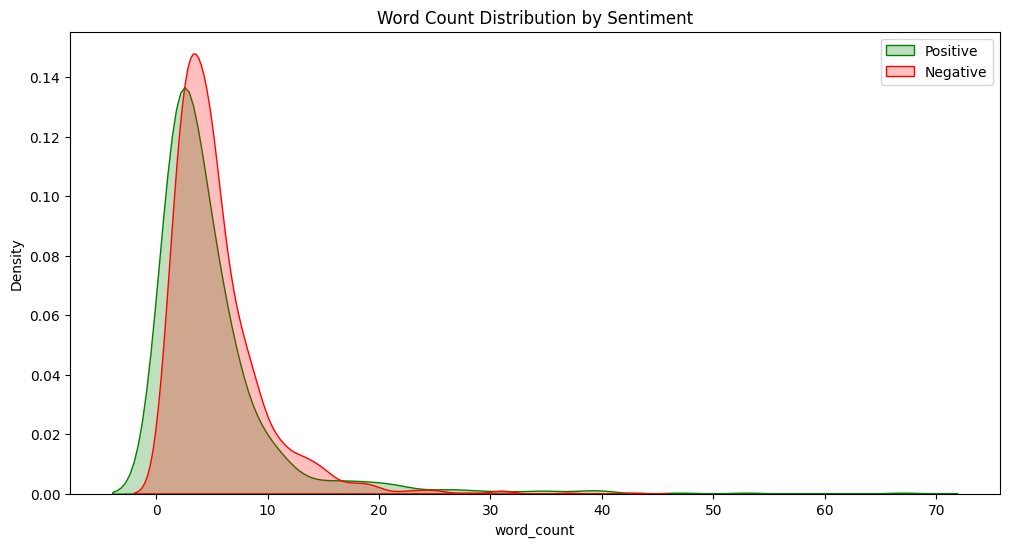

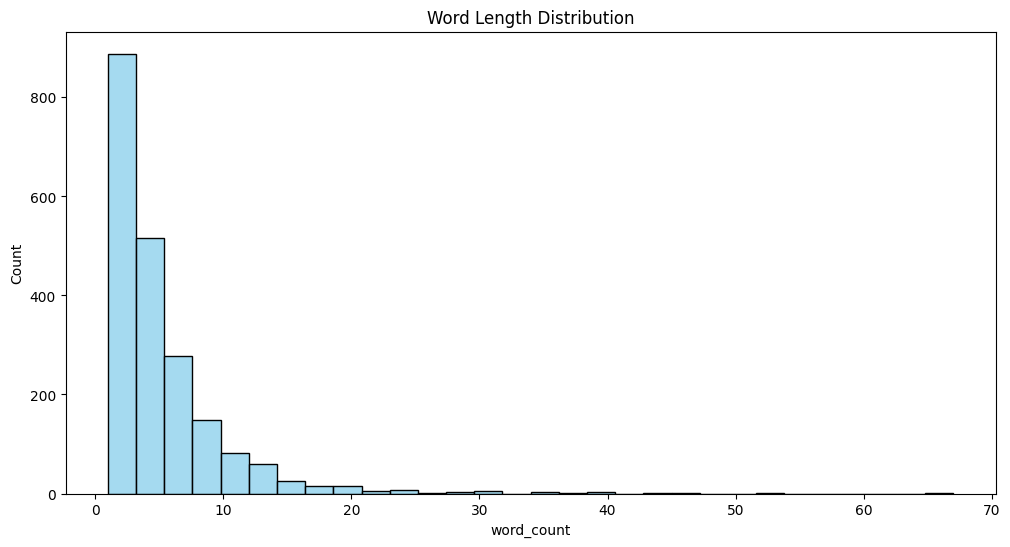

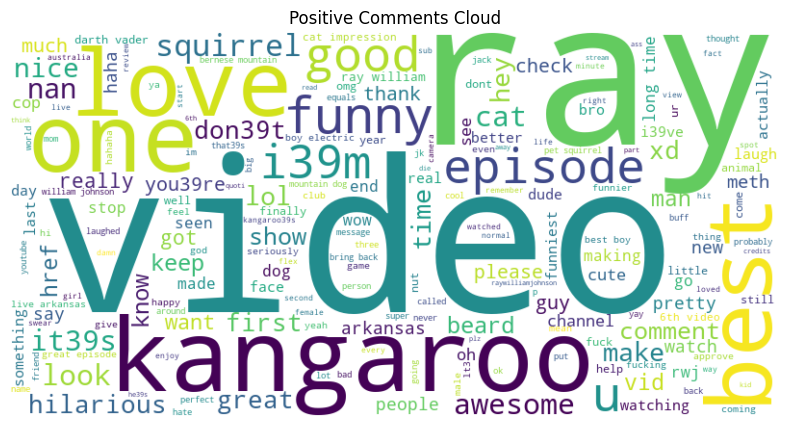

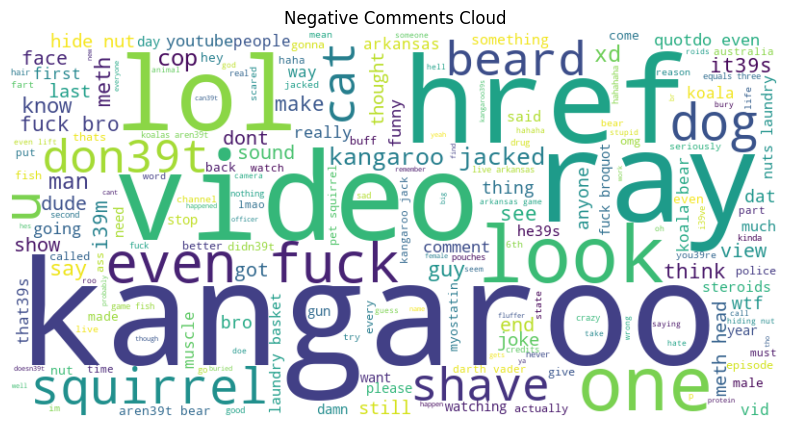

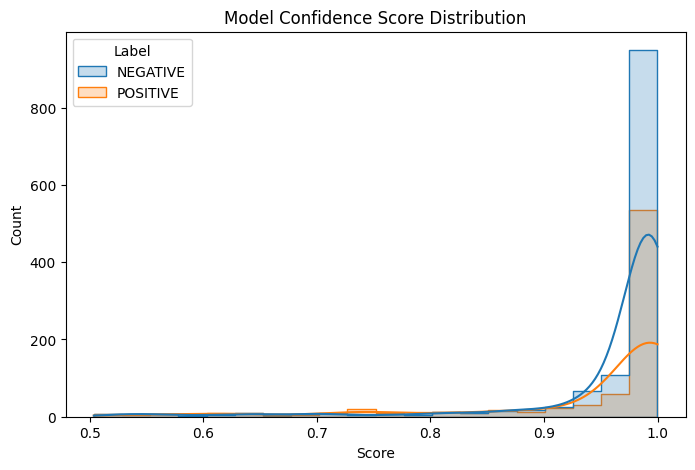

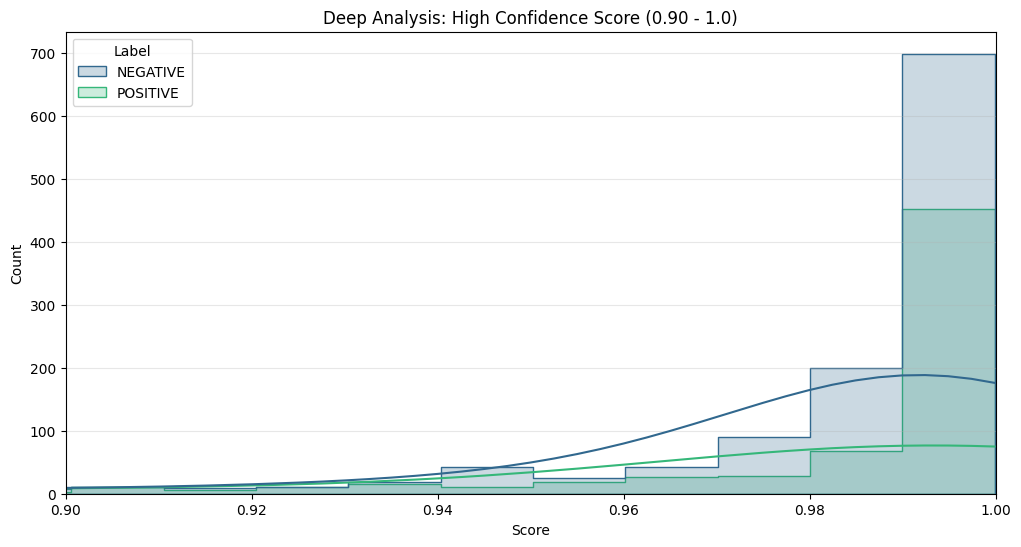

Saaare graphs 'artifacts/eda_report' folder mein save ho gaye hain!
[05-05-2026 11:12:22 PM - 1845437083 - INFO - Reports Downloaded Successfully...artifacts/eda_report...✅]
[05-05-2026 11:12:22 PM - 100433989 - INFO - Pipeline Ran Sucessfully...✅]


In [25]:
try:
    cfm = ConfigurationManager()
    data_report = cfm.get_eda_report()
    data_report_component = EDAReportComponent(data_report)
    
    data_report_component.download()
    logger.info("Pipeline Ran Sucessfully...✅")
except Exception as e:
    logger.error("Pipeline Error...❌")
    raise e
